# NB2 — ICDM Square Model-Family

**The model-family axis (spec §5).** Covers MLP / XGBoost / Ensemble on the
model-agnostic Square attack (score-based black-box, 100-query budget, ε=0.1)
at Protocol A and derived Protocol B — the cross-model-comparable table
TabularBench cannot produce. 36 Square runs (4 datasets × 3 models × 3 seeds),
defence = `none`, ~6 h total (the only real compute in the ICDM scope).

- **A_unconstrained** — stock Square (processed-schema clipping only).
- **B_posthoc_filter** — feasibility filter on A's saved examples (infeasible → revert to clean). *Derived, no new attack.*
- **Protocol C is NOT run here:** white-box in-attack constraints are MLP/CAPGD-only (NB1);
  Cartella-style black-box in-attack C for XGBoost/Ensemble is deferred to future work —
  recorded as `protocol = "N/A"` placeholder rows (spec §5.2).

**Multi-session safe:** all outputs (CSV + parquet + figures) write directly to
Drive; re-running the notebook resumes from the completed `run_id`s. Cell 13
prints what remains.

**Bootstrap cells 1–5** mirror NB1 (Drive mount, repo clone, deps install → restart, dataset symlinks).

Outputs: adversarial parquet under `FraudBench/results/adv_examples/icdm_square_family/`;
`square_family_results.csv` / `_summary.csv` + `fig_model_family` under `FraudBench/results/icdm_2026/`.

In [1]:
# Cell 1: Verify GPU
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = getattr(props, "total_memory", getattr(props, "total_mem", 0)) / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU")

GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


In [2]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
for subdir in ["data", "results", "results/adv_examples", "results/icdm_2026"]:
    os.makedirs(os.path.join(DRIVE_ROOT, subdir), exist_ok=True)
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [4]:
# Cell 3: Clone or update repo
import os, shutil

REPO_URL = "https://github.com/iHaydenzZ/Capstone_FraudBench.git"
REPO_DIR = "/content/Capstone_FraudBench"

if os.path.exists(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)
    !git pull
else:
    os.chdir("/content")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    !git clone {REPO_URL} {REPO_DIR}
    os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
!git log --oneline -3

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.59 KiB | 135.00 KiB/s, done.
From https://github.com/iHaydenzZ/Capstone_FraudBench
   23d60d8..ac539b3  master     -> origin/master
Updating 23d60d8..ac539b3
Fast-forward
 notebooks/icdm_capgd_protocol_grid.ipynb | 34 +++-----------------------------
 notebooks/icdm_square_model_family.ipynb | 16 ++-------------
 2 files changed, 5 insertions(+), 45 deletions(-)
Working directory: /content/Capstone_FraudBench
ac539b3 (HEAD -> master, origin/master, origin/HEAD) fix(notebooks): Colab bootstrap installed wrong 'art' package (ASCII-art, not ART)
23d60d8 docs(plans): NB2 Square model-family implementation plan (Codex-reviewed)
e178dd2 feat(notebooks): NB2 ICDM Square model-family (A/B + C-N/A placeholders, Drive-direct resume)


In [ ]:
# Cell 4: Install dependencies
!pip install "numpy<2.1" "scipy>=1.14,<1.15" "scikit-learn>=1.5" -q 2>&1 | tail -5
!pip install -e . --no-deps -q 2>&1 | tail -5
!pip install "numba>=0.61" -q 2>&1 | tail -3
# NB: ART's PyPI name is adversarial-robustness-toolbox; the PyPI package
# literally named 'art' is an ASCII-art library that shadows the same import
# namespace (-> "No module named 'art.attacks'"). Uninstall it if present.
!pip uninstall -y art -q 2>/dev/null
!pip install xgboost torch "adversarial-robustness-toolbox>=1.18.0" pyyaml joblib pandas matplotlib pyarrow -q 2>&1 | tail -3

# --- IMPORTANT ---
# After this cell finishes, restart the runtime:
#   Runtime > Restart session  (or Ctrl+M then .)
# Then skip this cell and continue from Cell 5.
print("\n>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<")

In [1]:
# Cell 5: Symlink datasets from Google Drive
import os

DRIVE_DATA = "/content/drive/MyDrive/FraudBench/data"
DATASETS_DIR = "/content/Capstone_FraudBench/datasets"

for dataset_dir in ["CCFD", "ieee-fraud-detection", "LCLD", "Sparkov"]:
    src = os.path.join(DRIVE_DATA, dataset_dir)
    dst = os.path.join(DATASETS_DIR, dataset_dir)
    if os.path.islink(dst):
        os.unlink(dst)
    if os.path.exists(src):
        os.symlink(src, dst)
        print(f"  Linked: {dataset_dir}/")
    else:
        print(f"  NOT FOUND: {dataset_dir}/ -- upload to {src}")

print("Dataset symlinks ready.")

  Linked: CCFD/
  Linked: ieee-fraud-detection/
  Linked: LCLD/
  Linked: Sparkov/
Dataset symlinks ready.


In [2]:
# Cell 6: Configuration and imports
import os, time, random, hashlib
import numpy as np
import pandas as pd
import torch

from datasets.loader import load_dataset
from datasets.splitter import split_dataset
from preprocessing.processor import DataPreprocessor
from constraints.schema import ConstraintSchema
from constraints.validator import EVAL_TOL
from constraints.feasibility import evaluate_feasibility
from models.neural import NeuralModel
from models.tree import TreeModel
from defences.ensemble import EnsembleModel
from attacks.square import square_attack
from evaluation.metrics import compute_metrics

# --- experiment axes (spec §5.2) ---
SEEDS = [42, 123, 456]
EPS = 0.1
SQUARE_PARAMS = {"epsilon": EPS, "max_iter": 100, "norm": "inf"}
SAMPLE_FRAC = 0.1                          # matches NB1 + the prior Square runs

# Per-family training params — reuse the repo configs that produced the prior
# Square registry rows (configs/*_tree_square.yaml, *_ensemble_square.yaml) and
# NB1's MLP (clean PR-AUC anchors, spec §5.3). NB: scale_pos_weight lives only
# inside the Ensemble's XGB component (defences/ensemble.py), not TreeModel.
MLP_PARAMS = {"epochs": 20, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}
XGB_PARAMS = {"max_depth": 6, "n_estimators": 100, "learning_rate": 0.1}
ENS_PARAMS = {"epochs": 15, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}

# (registry_name, loader_name)
DATASETS = [
    ("CCFD", "ccfd"),
    ("IEEE-CIS", "ieee_cis"),
    ("LCLD", "lcld"),
    ("Sparkov", "sparkov"),
]
MODELS = ["MLP", "XGBoost", "Ensemble"]

NB, DEFENCE, ATTACK = "nb2_square_family", "none", "Square"
# Spec §5.2's "protocol = N/A" placeholder marker. NOT the literal string "N/A":
# pandas' default na_values would convert that cell to NaN on read-back, and
# `protocol != "N/A"` filters would silently keep the placeholder rows.
PROTO_NA = "not_applicable"

# Outputs go straight to Drive when mounted (multi-session resume, spec §8);
# fall back to the local repo tree otherwise.
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
ROOT = DRIVE_ROOT if os.path.isdir(DRIVE_ROOT) else "."
ADV_DIR = os.path.join(ROOT, "results/adv_examples/icdm_square_family")
OUT_DIR = os.path.join(ROOT, "results/icdm_2026")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODELS_DIR = os.path.join(ROOT, "results/models/icdm_square_family")  # spec §1.9.1: persist weights
for d in (ADV_DIR, OUT_DIR, FIG_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)
RESULTS_CSV = os.path.join(OUT_DIR, "square_family_results.csv")
SUMMARY_CSV = os.path.join(OUT_DIR, "square_family_summary.csv")

# Canonical long-format schema (spec §3.1).
RESULTS_COLUMNS = [
    "run_id", "notebook", "dataset", "model", "defence", "attack", "protocol",
    "seed", "epsilon", "same_model_group_id", "model_weight_hash", "n_test",
    "clean_pr_auc", "robust_pr_auc", "clean_roc_auc", "robust_roc_auc",
    "clean_accuracy", "robust_accuracy", "flipped_count", "feasible_count",
    "feasible_flipped_count", "fsr", "aggregate_feasibility",
    "main_failed_constraint", "attack_runtime_sec", "notes",
]

print(f"EVAL_TOL = {EVAL_TOL}; outputs -> {os.path.abspath(ROOT)}")
print(f"Plan: {len(DATASETS)} datasets x {len(MODELS)} models x {len(SEEDS)} seeds = "
      f"{len(DATASETS) * len(MODELS) * len(SEEDS)} Square runs (A) + derived B")

EVAL_TOL = 1e-06; outputs -> /content/drive/MyDrive/FraudBench
Plan: 4 datasets x 3 models x 3 seeds = 36 Square runs (A) + derived B


In [3]:
# Cell 7: Reproducibility helpers + same-model training per group
def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def model_hash(model) -> str:
    """Stable 16-hex hash over the fitted parameters of any model family
    (spec §1.9): torch state_dict bytes for the MLP, the XGBoost booster's
    UBJSON dump for the tree, and the concatenation of all three sub-models
    (LR coefficients + booster + MLP weights) for the ensemble."""
    if isinstance(model, EnsembleModel):
        buf = (
            model.lr_model.coef_.tobytes() + model.lr_model.intercept_.tobytes()
            + bytes(model.xgb_model.get_booster().save_raw(raw_format="ubj"))
            + b"".join(p.detach().cpu().numpy().tobytes()
                       for p in model.mlp.state_dict().values())
        )
    elif isinstance(model, TreeModel):
        buf = bytes(model.model.get_booster().save_raw(raw_format="ubj"))
    else:  # NeuralModel
        buf = b"".join(p.detach().cpu().numpy().tobytes()
                       for p in model.model.state_dict().values())
    return hashlib.sha256(buf).hexdigest()[:16]


def build_model(model_name):
    if model_name == "MLP":
        return NeuralModel(dict(MLP_PARAMS))
    if model_name == "XGBoost":
        return TreeModel(dict(XGB_PARAMS))
    if model_name == "Ensemble":
        return EnsembleModel(dict(ENS_PARAMS))
    raise ValueError(f"Unknown model {model_name!r}")


def train_group(registry_name, loader_name, model_name, seed):
    """Train ONE model for a (dataset, model, seed) group (defence = none);
    reused by Protocol A's attack and B's derivation. Weights persist to
    MODELS_DIR (spec §1.9.1) so a multi-session resume reloads the *same*
    fitted model instead of retraining — the same-model hash is exact across
    sessions. Returns the fitted model, preprocessor, processed test split,
    the processed-space schema (Square's clip values), cached clean
    predictions, and the hash."""
    set_all_seeds(seed)
    dataset = load_dataset(loader_name, config={"sample_frac": SAMPLE_FRAC})
    X_train, _X_val, X_test, y_train, _y_val, y_test = split_dataset(
        dataset, test_size=0.2, val_size=0.2, random_state=seed
    )
    pre = DataPreprocessor(dataset.feature_types)
    X_train_p = pre.fit_transform(X_train)
    X_test_p = pre.transform(X_test)
    proc_ft = {c: "numeric" for c in X_train_p.columns}
    schema = ConstraintSchema.from_data(X_train_p, proc_ft)

    model = build_model(model_name)
    ext = ".pt" if model_name == "MLP" else ".joblib"
    ckpt = os.path.join(MODELS_DIR, f"{registry_name}__{model_name}__{DEFENCE}__s{seed}{ext}")
    t0 = time.time()
    if os.path.exists(ckpt):
        model = type(model).load(ckpt)
        verb = "loaded"
    else:
        model.fit(X_train_p, y_train)
        model.save(ckpt)
        verb = "trained"
    train_time = time.time() - t0

    grp = dict(
        model=model, pre=pre, schema=schema, proc_ft=proc_ft,
        X_test_p=X_test_p, y_test=y_test,
        clean_probs=model.predict_proba(X_test_p), hash=model_hash(model),
    )
    print(f"  {verb} {registry_name}/{model_name}/s{seed} in {train_time:.1f}s  "
          f"hash={grp['hash']}  n_test={len(y_test)}  proc_dim={X_test_p.shape[1]}")
    return grp

In [4]:
# Cell 8: Row builder (spec §3.1), Protocol-B derivation, CSV append
def make_run_id(reg, model_name, seed, eps, protocol):
    return f"{NB}__{reg}__{model_name}__{DEFENCE}__s{seed}__e{eps}__{protocol}"


def build_row(grp, reg, model_name, seed, protocol, X_adv, runtime):
    """One §3.1 results row. flipped_count = positives the clean model caught
    (pred=1) that the attack flipped to negative; feasible_flipped additionally
    requires the adv row to pass the full feasibility conjunction (identical
    definitions to NB1's build_rows)."""
    adv_probs = grp["model"].predict_proba(X_adv)
    clean_m = compute_metrics(grp["y_test"], grp["clean_probs"])
    rob_m = compute_metrics(grp["y_test"], adv_probs)
    feas = evaluate_feasibility(reg, X_adv, preprocessor=grp["pre"])

    yv = grp["y_test"].values
    clean_pred = (grp["clean_probs"] >= 0.5).astype(int)
    adv_pred = (adv_probs >= 0.5).astype(int)
    pos = yv == 1
    fmask = feas.feasible_row_mask.values
    flipped = int(((clean_pred == 1) & (adv_pred == 0) & pos).sum())
    feas_flipped = int(((clean_pred == 1) & (adv_pred == 0) & pos & fmask).sum())
    fsr = (feas_flipped / flipped) if flipped > 0 else float("nan")

    row = {
        "run_id": make_run_id(reg, model_name, seed, EPS, protocol),
        "notebook": NB, "dataset": reg, "model": model_name,
        "defence": DEFENCE, "attack": ATTACK, "protocol": protocol, "seed": seed,
        "epsilon": EPS, "same_model_group_id": f"{reg}__{model_name}__{DEFENCE}__s{seed}",
        "model_weight_hash": model_hash(grp["model"]), "n_test": int(len(yv)),
        "clean_pr_auc": clean_m["pr_auc"], "robust_pr_auc": rob_m["pr_auc"],
        "clean_roc_auc": clean_m["roc_auc"], "robust_roc_auc": rob_m["roc_auc"],
        "clean_accuracy": clean_m["accuracy"], "robust_accuracy": rob_m["accuracy"],
        "flipped_count": flipped, "feasible_count": int(fmask.sum()),
        "feasible_flipped_count": feas_flipped, "fsr": fsr,
        "aggregate_feasibility": feas.aggregate_feasibility,
        "main_failed_constraint": feas.main_failed_constraint,
        "attack_runtime_sec": round(runtime, 3), "notes": "",
    }
    return row, feas


def derive_protocol_B(A_adv, A_feas_mask, X_test_p):
    """Protocol B: keep feasible A rows, revert infeasible rows to clean."""
    B = A_adv.copy()
    B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]
    return B


def append_csv(path, rows, columns=None):
    if not rows:
        return
    df = pd.DataFrame(rows)
    if columns is not None:
        df = df[columns]
    df.to_csv(path, mode="a", header=not os.path.exists(path), index=False)

In [5]:
# Cell 9: Main loop — one Square run (A) + derived B per (dataset, model, seed); resumable
done = set(pd.read_csv(RESULTS_CSV)["run_id"]) if os.path.exists(RESULTS_CSV) else set()
print(f"Resuming: {len(done)} run_ids already complete.")

t_session = time.time()
for reg, loader_name in DATASETS:
    for model_name in MODELS:
        for seed in SEEDS:
            a_rid = make_run_id(reg, model_name, seed, EPS, "A_unconstrained")
            b_rid = make_run_id(reg, model_name, seed, EPS, "B_posthoc_filter")
            if a_rid in done and b_rid in done:
                continue

            print(f"\n=== {reg} | {model_name} | seed {seed} ===")
            grp = train_group(reg, loader_name, model_name, seed)
            parq = os.path.join(ADV_DIR, a_rid + ".parquet")

            if a_rid in done:
                # Session died between A and B last time: reuse A's parquet
                # against the checkpoint-reloaded model (hashes must agree).
                assert os.path.exists(parq), (
                    f"{a_rid} is in the CSV but its parquet is missing ({parq}). "
                    "Recovery: delete the A row from the CSV and re-run this group.")
                A_adv = pd.read_parquet(parq)
                stored = pd.read_csv(RESULTS_CSV).set_index("run_id").loc[a_rid, "model_weight_hash"]
                assert stored == grp["hash"], (
                    f"checkpoint hash {grp['hash']} != stored A hash {stored} for {a_rid}. "
                    "The Drive checkpoint was likely deleted and the model retrained. "
                    "Recovery: delete this group's A/B rows, parquet, and checkpoint, then re-run.")
                A_feas = evaluate_feasibility(reg, A_adv, preprocessor=grp["pre"]).feasible_row_mask
            else:
                t0 = time.time()
                A_adv = square_attack(grp["model"], grp["X_test_p"], grp["y_test"],
                                      grp["schema"], grp["proc_ft"], params=dict(SQUARE_PARAMS))
                rt = time.time() - t0
                A_adv.to_parquet(parq)
                A_adv = pd.read_parquet(parq)   # spec §1.9.3: B + feasibility derive from the
                                                # SAVED file; also validates the Drive write
                row, feas = build_row(grp, reg, model_name, seed, "A_unconstrained", A_adv, rt)
                assert row["model_weight_hash"] == grp["hash"], \
                    f"model hash drift in {a_rid}: {row['model_weight_hash']} != {grp['hash']}"
                append_csv(RESULTS_CSV, [row], RESULTS_COLUMNS)
                done.add(a_rid)
                A_feas = feas.feasible_row_mask
                print(f"  [{'A_unconstrained':>16}] robPR={row['robust_pr_auc']:.3f}  "
                      f"flip={row['flipped_count']}  feasflip={row['feasible_flipped_count']}  "
                      f"FSR={row['fsr']:.3f}  agg={row['aggregate_feasibility']:.4f}  "
                      f"bind={row['main_failed_constraint']}  ({rt / 60:.1f} min)")

            if b_rid not in done:
                B_adv = derive_protocol_B(A_adv, A_feas, grp["X_test_p"])
                B_adv.to_parquet(os.path.join(ADV_DIR, b_rid + ".parquet"))
                brow, _ = build_row(grp, reg, model_name, seed, "B_posthoc_filter", B_adv, 0.0)
                brow["notes"] = "derived from A_unconstrained (post-hoc feasibility filter)"
                append_csv(RESULTS_CSV, [brow], RESULTS_COLUMNS)
                done.add(b_rid)
                print(f"  [{'B_posthoc_filter':>16}] robPR={brow['robust_pr_auc']:.3f}  "
                      f"flip={brow['flipped_count']}  feasflip={brow['feasible_flipped_count']}  "
                      f"FSR={brow['fsr']:.3f}")

print(f"\nSession done in {(time.time() - t_session) / 3600:.2f} h. Total run_ids: {len(done)}")

Resuming: 0 run_ids already complete.

=== CCFD | MLP | seed 42 ===
    Split indices saved to results/split_indices_ccfd_n28481_seed42.json
  Using class weights (pos_weight=609.29)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.0480
Epoch 10/20, Loss: 0.0127
Epoch 15/20, Loss: 0.0190
Epoch 20/20, Loss: 0.0132
  trained CCFD/MLP/s42 in 10.7s  hash=e3dd8b326652aa95  n_test=5697  proc_dim=30
  [ A_unconstrained] robPR=0.900  flip=0  feasflip=0  FSR=nan  agg=1.0000  bind=none  (0.1 min)
  [B_posthoc_filter] robPR=0.900  flip=0  feasflip=0  FSR=nan

=== CCFD | MLP | seed 123 ===
    Split indices saved to results/split_indices_ccfd_n28481_seed123.json
  Using class weights (pos_weight=609.29)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.0600
Epoch 10/20, Loss: 0.0126
Epoch 15/20, Loss: 0.0060
Epoch 20/20, Loss: 0.0044
  trained CCFD/MLP/s123 in 4.1s  hash=fdafb08d6bf217ba  n_test=5697  proc_dim=30
  [ A_unconstrained] robPR=0.534  flip=0  feasflip=0  FSR=nan  agg=1.0000  bin

/tmp/ipykernel_5200/3894061246.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[-0.51389311  1.06786134 -0.18140326 ...  1.          0.
   0.        ]
 [ 1.38484479 -0.32182904  1.51473839 ...  0.          0.
   1.        ]
 [ 1.42720391  1.35129527 -0.41729454 ...  0.          1.
   0.        ]
 ...
 [-1.37354585 -0.20413483  1.63623967 ...  0.          1.
   0.        ]
 [ 1.5085224  -0.09352646  0.19894858 ...  0.          1.
   0.        ]
 [ 1.06408122 -0.23541625 -0.41952952 ...  0.          0.
   1.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [B_posthoc_filter] robPR=0.448  flip=0  feasflip=0  FSR=nan

=== IEEE-CIS | MLP | seed 123 ===
    Split indices saved to results/split_indices_ieee_cis_n59054_seed123.json
  Using class weights (pos_weight=27.01)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.7661
Epoch 10/20, Loss: 0.5454
Epoch 15/20, Loss: 0.3799
Epoch 20/20, Loss: 0.2818
  trained IEEE-CIS/MLP/s123 in 9.0s  hash=f9a503fc4c8ba05a  n_test=11811  proc_dim=537
  [ A_unconstrained] robPR=0.117  flip=175  feasflip=0  FSR=0.000  agg=0.1950  bind=i_card6_ohe  (0.5 min)


/tmp/ipykernel_5200/3894061246.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[ 0.45786648 -0.40172668  1.29358949 ...  0.          0.
   1.        ]
 [ 0.31347627 -0.0634915   1.488958   ...  0.          1.
   0.        ]
 [ 0.12371555  0.26062149 -1.08536961 ...  0.          1.
   0.        ]
 ...
 [-0.95417026 -0.22975327  1.25884822 ...  0.          0.
   1.        ]
 [-0.70080801 -0.20296992 -1.49613396 ...  0.          0.
   1.        ]
 [ 1.31925284 -0.36856568  0.00305373 ...  0.          0.
   1.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [B_posthoc_filter] robPR=0.453  flip=0  feasflip=0  FSR=nan

=== IEEE-CIS | MLP | seed 456 ===
    Split indices saved to results/split_indices_ieee_cis_n59054_seed456.json
  Using class weights (pos_weight=27.01)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.7332
Epoch 10/20, Loss: 0.5402
Epoch 15/20, Loss: 0.3762
Epoch 20/20, Loss: 0.2598
  trained IEEE-CIS/MLP/s456 in 9.0s  hash=a38b2061efc308c2  n_test=11811  proc_dim=538
  [ A_unconstrained] robPR=0.082  flip=196  feasflip=0  FSR=0.000  agg=0.2741  bind=i_card4_ohe  (0.5 min)


...

  [B_posthoc_filter] robPR=0.566  flip=0  feasflip=0  FSR=nan

=== Sparkov | Ensemble | seed 123 ===
    Reusing existing split indices for sparkov (n=185239, seed=123)
  Training Ensemble (LR + XGBoost + MLP)...
    [1/3] LogisticRegression...
    [2/3] XGBClassifier...
    [3/3] SimpleMLP...
      MLP Epoch 5/15, Loss: 0.4194
      MLP Epoch 10/15, Loss: 0.2693
      MLP Epoch 15/15, Loss: 0.1799
  trained Sparkov/Ensemble/s123 in 24.1s  hash=8d780643b71f9d5e  n_test=37048  proc_dim=75
  [ A_unconstrained] robPR=0.065  flip=73  feasflip=0  FSR=0.000  agg=0.0136  bind=s_state_ohe  (8.8 min)


/tmp/ipykernel_5200/3894061246.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[ 0.55850957  1.86275648  1.70833301 ...  0.          0.
   0.        ]
 [ 0.23986076 -0.45325795 -1.18242963 ...  0.          0.
   0.        ]
 [ 0.37131572 -0.99013125  0.05930562 ...  0.          0.
   0.        ]
 ...
 [-0.24945754 -1.19289965  0.48517979 ...  0.          0.
   0.        ]
 [-0.39182598 -1.19215595  0.47520128 ...  0.          0.
   0.        ]
 [-0.06349686  0.03111049  1.41915264 ...  0.          0.
   0.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [B_posthoc_filter] robPR=0.417  flip=0  feasflip=0  FSR=nan

=== Sparkov | Ensemble | seed 456 ===
    Reusing existing split indices for sparkov (n=185239, seed=456)
  Training Ensemble (LR + XGBoost + MLP)...
    [1/3] LogisticRegression...
    [2/3] XGBClassifier...
    [3/3] SimpleMLP...
      MLP Epoch 5/15, Loss: 0.3768
      MLP Epoch 10/15, Loss: 0.1917
      MLP Epoch 15/15, Loss: 0.1410
  trained Sparkov/Ensemble/s456 in 23.7s  hash=51bd73ca6591e968  n_test=37048  proc_dim=75
  [ A_unconstrained] robPR=0.084  flip=79  feasflip=0  FSR=0.000  agg=0.0159  bind=s_state_ohe  (8.8 min)


/tmp/ipykernel_5200/3894061246.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[[-0.3620951   0.49535979  0.07812994 ...  0.          0.
   0.        ]
 [ 0.15075283  0.9787364  -1.14775039 ...  0.          0.
   0.        ]
 [-0.39401374 -0.99675906  0.07111773 ...  0.          0.
   0.        ]
 ...
 [-0.34750372  0.03459837  1.53604188 ...  0.          0.
   0.        ]
 [ 0.19550407 -0.49870306 -0.82228153 ...  0.          0.
   0.        ]
 [-0.44580011  1.12836184 -0.83237755 ...  0.          0.
   0.        ]]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  B.loc[~A_feas_mask] = X_test_p.loc[~A_feas_mask]


  [B_posthoc_filter] robPR=0.537  flip=0  feasflip=0  FSR=nan

Session done in 3.30 h. Total run_ids: 72


In [6]:
# Cell 10: Protocol-C placeholder rows for XGBoost / Ensemble (spec §5.2)
# Black-box in-attack constraint enforcement (Cartella et al. 2021) is deferred:
# one explicit placeholder row per (dataset, tree-family model, seed) so the
# master registry and NB3's coverage table show the gap instead of silently
# omitting it. protocol = PROTO_NA ("not_applicable") encodes spec §5.2's
# "N/A" in a pandas-safe form; NB3 must filter protocol != PROTO_NA before
# computing metrics.
CARTELLA_NOTE = "Cartella-style black-box in-attack Protocol C deferred to future work"

res = pd.read_csv(RESULTS_CSV)
existing = set(res["run_id"])
a_rows = res[res["protocol"] == "A_unconstrained"].set_index("same_model_group_id")

NAN_COLS = ["clean_pr_auc", "robust_pr_auc", "clean_roc_auc", "robust_roc_auc",
            "clean_accuracy", "robust_accuracy", "flipped_count", "feasible_count",
            "feasible_flipped_count", "fsr", "aggregate_feasibility"]
na_rows = []
for reg, _loader in DATASETS:
    for model_name in ["XGBoost", "Ensemble"]:
        for seed in SEEDS:
            rid = make_run_id(reg, model_name, seed, EPS, PROTO_NA)
            gid = f"{reg}__{model_name}__{DEFENCE}__s{seed}"
            if rid in existing or gid not in a_rows.index:
                continue   # already emitted, or the A row doesn't exist yet
            a = a_rows.loc[gid]
            na_rows.append({
                "run_id": rid, "notebook": NB, "dataset": reg, "model": model_name,
                "defence": DEFENCE, "attack": ATTACK, "protocol": PROTO_NA, "seed": seed,
                "epsilon": EPS, "same_model_group_id": gid,
                "model_weight_hash": a["model_weight_hash"], "n_test": int(a["n_test"]),
                **{c: float("nan") for c in NAN_COLS},
                "main_failed_constraint": "", "attack_runtime_sec": float("nan"),
                "notes": CARTELLA_NOTE,
            })
append_csv(RESULTS_CSV, na_rows, RESULTS_COLUMNS)
print(f"Appended {len(na_rows)} Protocol-C placeholder rows (protocol={PROTO_NA}; "
      f"total expected: {len(DATASETS) * 2 * len(SEEDS)}).")

Appended 24 Protocol-C placeholder rows (protocol=not_applicable; total expected: 24).


In [7]:
# Cell 11: Per-(dataset,model,protocol) summary over seeds (spec §3.3) + §5.3 sanity checks
res = pd.read_csv(RESULTS_CSV)
measured = res[res["protocol"] != PROTO_NA]
metrics_m = ["robust_pr_auc", "robust_roc_auc", "flipped_count",
             "feasible_flipped_count", "fsr", "aggregate_feasibility", "robust_accuracy"]
grp = measured.groupby(["dataset", "model", "defence", "protocol", "epsilon"])
summ = grp[metrics_m].agg(["mean", "std"])
summ.columns = [f"{stat}_{m}" for m, stat in summ.columns]
summ = summ.reset_index()
summ["n_seeds"] = grp.size().values
summ.to_csv(SUMMARY_CSV, index=False)
print(f"Saved summary ({len(summ)} groups) -> {SUMMARY_CSV}\n")

cols = ["dataset", "model", "protocol", "mean_robust_pr_auc", "std_robust_pr_auc",
        "mean_fsr", "mean_feasible_flipped_count", "mean_aggregate_feasibility"]
print(summ[cols].to_string(index=False))

# Check 1 — MLP clean PR-AUC anchors (spec §5.3).
ANCHORS = {"CCFD": 0.633, "IEEE-CIS": 0.428, "LCLD": 0.302, "Sparkov": 0.606}
mlp_a = measured[(measured["model"] == "MLP") & (measured["protocol"] == "A_unconstrained")]
print("\nMLP clean PR-AUC vs anchors (spec §5.3):")
for ds, anchor in ANCHORS.items():
    got = mlp_a[mlp_a["dataset"] == ds]["clean_pr_auc"].mean()
    flag = "OK" if abs(got - anchor) < 0.05 else "DEVIATES — record in experiment_status.md"
    print(f"  {ds:9s} {got:.3f} vs {anchor:.3f}  [{flag}]")

# Check 2 — CCFD negative control: A ≈ B for every model (gap ≈ 1x).
ccfd = summ[summ["dataset"] == "CCFD"].pivot(index="model", columns="protocol",
                                             values="mean_robust_pr_auc")
ccfd["gap_B_over_A"] = ccfd["B_posthoc_filter"] / ccfd["A_unconstrained"]
print("\nCCFD A vs B (negative control, expect gap ≈ 1x):")
print(ccfd.to_string())

Saved summary (24 groups) -> /content/drive/MyDrive/FraudBench/results/icdm_2026/square_family_summary.csv

 dataset    model         protocol  mean_robust_pr_auc  std_robust_pr_auc  mean_fsr  mean_feasible_flipped_count  mean_aggregate_feasibility
    CCFD Ensemble  A_unconstrained            0.727751           0.236871  1.000000                     0.666667                    1.000000
    CCFD Ensemble B_posthoc_filter            0.727751           0.236871  1.000000                     0.666667                    1.000000
    CCFD      MLP  A_unconstrained            0.650794           0.215949       NaN                     0.000000                    1.000000
    CCFD      MLP B_posthoc_filter            0.650794           0.215949       NaN                     0.000000                    1.000000
    CCFD  XGBoost  A_unconstrained            0.774489           0.223214  1.000000                     0.666667                    1.000000
    CCFD  XGBoost B_posthoc_filter            

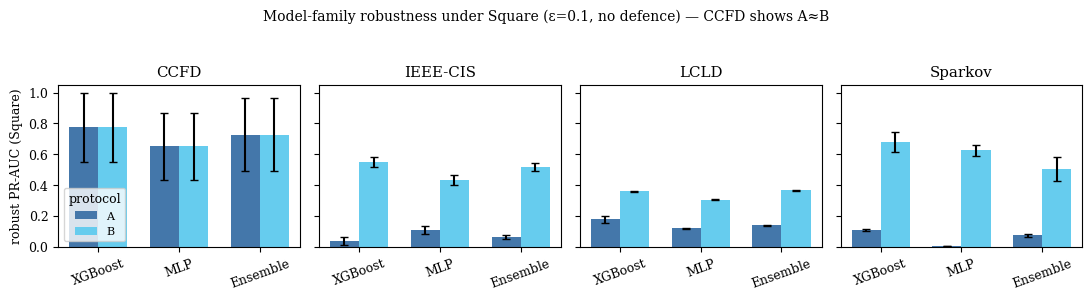

Saved fig_model_family.{pdf,png}


In [8]:
# Cell 12: fig_model_family — robust PR-AUC (Square) by model family, A vs B (spec §5.4)
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({"font.family": "serif", "font.size": 9})
PROTO_COLOR = {"A_unconstrained": "#4477aa", "B_posthoc_filter": "#66ccee"}
PROTO_LABEL = {"A_unconstrained": "A", "B_posthoc_filter": "B"}
MODEL_ORDER = ["XGBoost", "MLP", "Ensemble"]

fig, axes = plt.subplots(1, 4, figsize=(11, 3), sharey=True)
for j, (ds, _loader) in enumerate(DATASETS):
    ax = axes[j]
    sub = summ[summ["dataset"] == ds]
    x = np.arange(len(MODEL_ORDER))
    width = 0.36
    for k, proto in enumerate(["A_unconstrained", "B_posthoc_filter"]):
        s = sub[sub["protocol"] == proto].set_index("model").reindex(MODEL_ORDER)
        ax.bar(x + (k - 0.5) * width, s["mean_robust_pr_auc"], width,
               yerr=s["std_robust_pr_auc"].fillna(0), capsize=3,
               color=PROTO_COLOR[proto], label=PROTO_LABEL[proto])
    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=20)
    if j == 0:
        ax.set_ylabel("robust PR-AUC (Square)")
        ax.legend(fontsize=8, title="protocol")
fig.suptitle("Model-family robustness under Square (ε=0.1, no defence) — CCFD shows A≈B",
             fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.93])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIG_DIR, f"fig_model_family.{ext}"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_model_family.{pdf,png}")

In [9]:
# Cell 13: Session status — what's done, what remains (multi-session runbook)
expected = [make_run_id(reg, m, s, EPS, p)
            for reg, _loader in DATASETS for m in MODELS for s in SEEDS
            for p in ["A_unconstrained", "B_posthoc_filter"]]
done_now = set(pd.read_csv(RESULTS_CSV)["run_id"]) if os.path.exists(RESULTS_CSV) else set()
remaining = [r for r in expected if r not in done_now]
print(f"Measured rows: {len(expected) - len(remaining)}/{len(expected)}")
if remaining:
    print(f"Remaining ({len(remaining)}):")
    for r in remaining:
        print("  ", r)
    print("\nNext session: run cells 1-5 (restart runtime after 4), then 6-9.")
else:
    print("All 72 measured rows complete. Run cells 10-12 for placeholders, summary, figure.")

Measured rows: 72/72
All 72 measured rows complete. Run cells 10-12 for placeholders, summary, figure.


## Notes

- **Same-model proof:** B is derived from A's saved parquet and evaluated
  against the same fitted model; the A row asserts
  `model_weight_hash == model_hash(trained model)`. Weights persist to
  `MODELS_DIR` on Drive (spec §1.9.1), so a resume after a dead session
  *reloads* the identical model — Cell 9 asserts the stored A hash matches
  the reloaded checkpoint's hash before deriving B.
- **XGBoost config** reuses `configs/*_tree_square.yaml` exactly (max_depth=6,
  n_estimators=100, lr=0.1, no scale_pos_weight) so the fresh layer is
  comparable to the prior Square registry rows; `scale_pos_weight` lives only
  inside the Ensemble's XGB component (`defences/ensemble.py`), which is what
  spec §1.3's parenthetical refers to.
- **Protocol A semantics match NB1:** `attacks/square.py` clips to processed
  schema bounds (ART clip_values + post-attack numeric clip) — the same
  envelope stock CAPGD applies per step — and adds no feasibility constraints.
- **Protocol C placeholder rows** (Cell 10) implement spec §5.2's
  `protocol = N/A`, encoded as `"not_applicable"` — a literal `"N/A"` cell is
  in pandas' default `na_values` and round-trips to `NaN`, silently leaking
  placeholders through `!= "N/A"` filters. NB3 must filter
  `protocol != "not_applicable"` before computing metrics.
- **Expected shape (§5.3):** CCFD is the negative control (A ≈ B, gap ≈ 1×);
  Square on the MLP should degrade PR-AUC *less* than CAPGD did in NB1
  (black-box, weaker attack) — a different attack, not a contradiction.